# Warehouse Management with Reinforcement Learning — Hub-and-Spoke Model

## 3 Warehouses (1 Hub + 2 Spokes) - Seasonal Demand - Import & Transfer Actions

### Comparison: Value Iteration vs Q-Learning vs Q-Learning with Function Approximation

**Hub-and-Spoke design**: W1 is a central hub with cheap imports (1$/unit) and large capacity (30). W2/W3 are spokes with expensive imports (5$/unit) and small capacity (15). Transfers from hub to spokes are cheap (0.5$/unit), making it optimal to import at the hub and redistribute.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

def save_figure(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=300, bbox_inches="tight")

from discrete_warehouse_env import (
    WarehouseEnv, ACTIONS, N_ACTIONS, demand_mean, DEMAND_PARAMS,
    DEFAULT_CAPACITIES, DEFAULT_IMPORT_COSTS, DEFAULT_HOLDING_COSTS, DEFAULT_TRANSFER_COSTS,
)


SEED = 42
np.random.seed(SEED)

# Environment parameters
CAPACITIES = DEFAULT_CAPACITIES
N_MONTHS = 12
GAMMA = 0.95
TRAIN_EPISODES = 50_000
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.99995
TABULAR_INIT_COST_PER_MONTH = 80.0

env = WarehouseEnv(capacities=CAPACITIES, n_months=N_MONTHS, seed=SEED)
print(f"Number of actions: {N_ACTIONS}")
print(f"Capacities: W1(hub)={CAPACITIES[0]}, W2={CAPACITIES[1]}, W3={CAPACITIES[2]}")
print(f"Import costs: W1(hub)={DEFAULT_IMPORT_COSTS[0]}, W2={DEFAULT_IMPORT_COSTS[1]}, W3={DEFAULT_IMPORT_COSTS[2]}")
print(f"Holding costs: W1(hub)={DEFAULT_HOLDING_COSTS[0]}, W2={DEFAULT_HOLDING_COSTS[1]}, W3={DEFAULT_HOLDING_COSTS[2]}")
print(f"Transfer costs: hub->spoke={DEFAULT_TRANSFER_COSTS[(0,1)]}, spoke->hub={DEFAULT_TRANSFER_COSTS[(1,0)]}, spoke->spoke={DEFAULT_TRANSFER_COSTS[(1,2)]}")
print(f"Episode length: {N_MONTHS} months")
print(f"Training episodes (all learning methods): {TRAIN_EPISODES}")
print(f"Initial tabular Q-value rule: -{TABULAR_INIT_COST_PER_MONTH:.0f} * remaining_months")
print()
for i in range(N_ACTIONS):
    print(f"  Action {i}: {env.describe_action(i)}")

Number of actions: 34
Capacities: W1(hub)=30, W2=15, W3=15
Import costs: W1(hub)=1.0, W2=5.0, W3=5.0
Holding costs: W1(hub)=0.3, W2=1.0, W3=1.0
Transfer costs: hub->spoke=0.5, spoke->hub=1.5, spoke->spoke=3.0
Episode length: 12 months
Training episodes (all learning methods): 50000
Initial tabular Q-value rule: -80 * remaining_months

  Action 0: no-op
  Action 1: import 2 to W1
  Action 2: import 4 to W1
  Action 3: import 6 to W1
  Action 4: import 2 to W2
  Action 5: import 4 to W2
  Action 6: import 6 to W2
  Action 7: import 2 to W3
  Action 8: import 4 to W3
  Action 9: import 6 to W3
  Action 10: transfer 2 from W1 to W2
  Action 11: transfer 4 from W1 to W2
  Action 12: transfer 2 from W1 to W3
  Action 13: transfer 4 from W1 to W3
  Action 14: transfer 2 from W2 to W1
  Action 15: transfer 4 from W2 to W1
  Action 16: transfer 2 from W2 to W3
  Action 17: transfer 4 from W2 to W3
  Action 18: transfer 2 from W3 to W1
  Action 19: transfer 4 from W3 to W1
  Action 20: transfer 

## 1. Demand Visualization

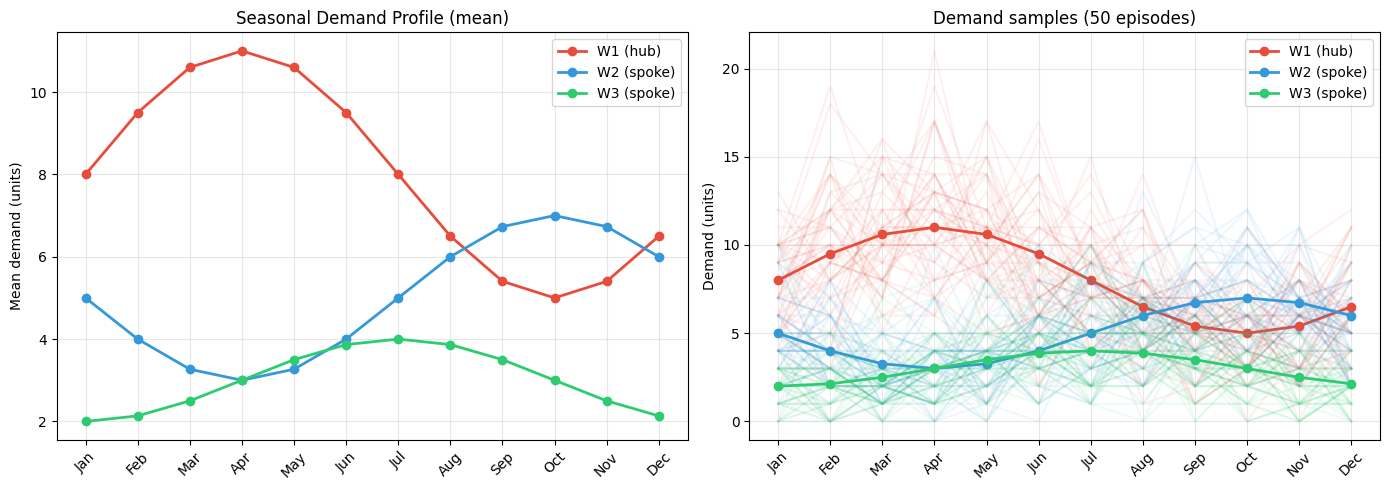

In [2]:
months = np.arange(12)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
wh_names = ["W1 (hub)", "W2 (spoke)", "W3 (spoke)"]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean demand per month
ax = axes[0]
for i in range(3):
    means = [demand_mean(i, m) for m in months]
    ax.plot(months, means, "o-", color=colors[i], label=wh_names[i], linewidth=2)
ax.set_xticks(months)
ax.set_xticklabels(month_labels, rotation=45)
ax.set_ylabel("Mean demand (units)")
ax.set_title("Seasonal Demand Profile (mean)")
ax.legend()
ax.grid(True, alpha=0.3)

# Sample demand realizations
ax = axes[1]
rng = np.random.default_rng(SEED)
n_samples = 50
for i in range(3):
    for s in range(n_samples):
        demands = [rng.poisson(demand_mean(i, m)) for m in months]
        ax.plot(months, demands, color=colors[i], alpha=0.08)
    means = [demand_mean(i, m) for m in months]
    ax.plot(months, means, "o-", color=colors[i], label=wh_names[i], linewidth=2)
ax.set_xticks(months)
ax.set_xticklabels(month_labels, rotation=45)
ax.set_ylabel("Demand (units)")
ax.set_title(f"Demand samples ({n_samples} episodes)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, "demand_visualization")
plt.show()

## 2. Baselines

### 2.1 Random Policy
### 2.2 Heuristic (Rule-Based) Policy

In [ ]:
def evaluate_policy(policy_fn, n_episodes=200, seed=SEED):
    """Evaluate a policy over n_episodes. Returns dict of metrics including per-warehouse breakdown."""
    eval_env = WarehouseEnv(capacities=CAPACITIES, n_months=N_MONTHS, seed=seed)
    
    all_rewards = []
    all_unmet = []
    all_imports = []
    all_transfers = []
    all_demands = []
    all_infeasible = []
    # Per-warehouse tracking
    all_imports_per_wh = []   # list of [imp_w1, imp_w2, imp_w3] per episode
    all_transfers_in = []     # units received per warehouse
    all_transfers_out = []    # units sent per warehouse
    
    for ep in range(n_episodes):
        state = eval_env.reset()
        ep_reward = 0
        ep_unmet = 0
        ep_imports = 0
        ep_transfers = 0
        ep_demand = 0
        ep_infeasible = 0
        ep_imports_per_wh = np.zeros(3)
        ep_transfers_in = np.zeros(3)
        ep_transfers_out = np.zeros(3)
        
        while True:
            action = policy_fn(state)
            next_state, reward, done, info = eval_env.step(action)
            ep_reward += reward
            ep_unmet += np.sum(info["unmet"])
            ep_imports += np.sum(info["actual_imports"])
            ep_transfers += info["total_transferred"]
            ep_demand += np.sum(info["demands"])
            ep_infeasible += info["infeasible_count"]
            ep_imports_per_wh += info["actual_imports"]
            for src, dst, qty in info["transfer_details"]:
                ep_transfers_out[src] += qty
                ep_transfers_in[dst] += qty
            state = next_state
            if done:
                break
        
        all_rewards.append(ep_reward)
        all_unmet.append(ep_unmet)
        all_imports.append(ep_imports)
        all_transfers.append(ep_transfers)
        all_demands.append(ep_demand)
        all_infeasible.append(ep_infeasible)
        all_imports_per_wh.append(ep_imports_per_wh.copy())
        all_transfers_in.append(ep_transfers_in.copy())
        all_transfers_out.append(ep_transfers_out.copy())
    
    total_demand = np.array(all_demands)
    total_unmet = np.array(all_unmet)
    service_level = (total_demand - total_unmet) / total_demand * 100
    
    imports_per_wh = np.array(all_imports_per_wh)
    transfers_in = np.array(all_transfers_in)
    transfers_out = np.array(all_transfers_out)
    
    return {
        "reward_mean": np.mean(all_rewards),
        "reward_std": np.std(all_rewards),
        "unmet_mean": np.mean(all_unmet),
        "unmet_std": np.std(all_unmet),
        "imports_mean": np.mean(all_imports),
        "transfers_mean": np.mean(all_transfers),
        "service_level_mean": np.mean(service_level),
        "service_level_std": np.std(service_level),
        "infeasible_mean": np.mean(all_infeasible),
        "rewards": all_rewards,
        "imports_per_wh": np.mean(imports_per_wh, axis=0),
        "transfers_in_per_wh": np.mean(transfers_in, axis=0),
        "transfers_out_per_wh": np.mean(transfers_out, axis=0),
    }


# Random Policy
def random_policy(state):
    return np.random.randint(N_ACTIONS)


# Heuristic Policy
def heuristic_policy(state):
    s1, s2, s3, month = state
    stocks = [s1, s2, s3]
    caps = CAPACITIES
    
    # Spoke thresholds
    SPOKE_LOW = 4
    HUB_LOW = 8
    
    # If a spoke is critically low, transfer from hub if possible
    for spoke in [1, 2]:
        if stocks[spoke] < SPOKE_LOW and stocks[0] >= 4:
            # qty=4
            for a_idx in range(10, N_ACTIONS):
                action = ACTIONS[a_idx]
                if action["transfers"]:
                    src, dst, qty = action["transfers"][0]
                    if src == 0 and dst == spoke and qty == 4:
                        return a_idx
    
    # If hub is getting low, import large to hub
    if stocks[0] < HUB_LOW:
        return 31 if stocks[0] < 5 else 30  
    
    # If hub has surplus and any spoke is below half, distribute
    if stocks[0] > 15:
        for spoke in [1, 2]:
            if stocks[spoke] < caps[spoke] // 2:
                return 26  
    
    # Keep hub stocked 
    if stocks[0] < 20:
        return 3  
    
    # If hub full, push to spokes
    if stocks[0] >= caps[0] - 4:
        min_spoke = 1 if stocks[1] <= stocks[2] else 2
        for a_idx in range(10, N_ACTIONS):
            action = ACTIONS[a_idx]
            if action["transfers"]:
                src, dst, qty = action["transfers"][0]
                if src == 0 and dst == min_spoke and qty == 4:
                    return a_idx
    
    return 0  # no-op


print("Evaluating baselines...")
random_metrics = evaluate_policy(random_policy)
heuristic_metrics = evaluate_policy(heuristic_policy)

print(f"\n{'Metric':<25} {'Random':>12} {'Heuristic':>12}")
print("-" * 50)
for key in ["reward_mean", "reward_std", "unmet_mean", "imports_mean", "transfers_mean", "service_level_mean", "infeasible_mean"]:
    print(f"{key:<25} {random_metrics[key]:>12.2f} {heuristic_metrics[key]:>12.2f}")

Evaluating baselines...

Metric                          Random    Heuristic
--------------------------------------------------
reward_mean                   -1416.75      -977.21
reward_std                      155.05       109.25
unmet_mean                      127.25        86.28
imports_mean                     36.97        79.43
transfers_mean                   13.21        14.46
service_level_mean               33.97        55.25
infeasible_mean                  12.63         0.00


## 3. Method 1: Value Iteration (Dynamic Programming)

Requires full knowledge of the MDP (transition probabilities + reward function). We approximate the expectation over demand by enumerating likely demand values for each warehouse.

In [ ]:
from scipy.stats import poisson


def build_demand_scenarios(month, coverage=0.70, max_per_wh=5):
    """
    Build a list of (demand_vector, joint_probability) for the given month.
    For each warehouse, keep the top demand values covering at least coverage
    of the probability mass, then form joint scenarios.
    """
    per_wh = []
    for i in range(3):
        mu = demand_mean(i, month)
        hi = int(mu + 4 * np.sqrt(mu)) + 1
        vals = list(range(0, hi + 1))
        probs = [poisson.pmf(d, mu) for d in vals]
        indexed = sorted(enumerate(probs), key=lambda x: -x[1])
        cumsum = 0.0
        selected = []
        for idx, p in indexed:
            if cumsum >= coverage and len(selected) >= 3:
                break
            if len(selected) >= max_per_wh:
                break
            selected.append((vals[idx], p))
            cumsum += p
        total = sum(p for _, p in selected)
        selected = [(v, p / total) for v, p in selected]
        per_wh.append(selected)

    scenarios = []
    for d0, p0 in per_wh[0]:
        for d1, p1 in per_wh[1]:
            for d2, p2 in per_wh[2]:
                scenarios.append((np.array([d0, d1, d2], dtype=int), p0 * p1 * p2))
    return scenarios


# State coarsening for Q-learning
MAX_CAP = int(np.max(CAPACITIES))
STOCK_STEP = 2
STOCK_VALUES = list(range(0, MAX_CAP + 1, STOCK_STEP))
N_STOCK_VALS = len(STOCK_VALUES)


def coarsen_stock(s):
    """Round stock to nearest coarse value."""
    return min(STOCK_VALUES, key=lambda x: abs(x - s))


def coarsen_state(state):
    s1, s2, s3, m = state
    return (coarsen_stock(s1), coarsen_stock(s2), coarsen_stock(s3), m)


def q_init_for_state(state_c):
    month = state_c[3]
    return np.full(N_ACTIONS, -TABULAR_INIT_COST_PER_MONTH * (N_MONTHS - month), dtype=float)


def ensure_state(Q, state_c):
    if state_c not in Q:
        Q[state_c] = q_init_for_state(state_c)
    return Q[state_c]


def argmax_random_tie(values, rng):
    max_val = np.max(values)
    best = np.flatnonzero(np.isclose(values, max_val))
    return int(rng.choice(best))


# Coarser grid for Value Iteration (faster computation)
VI_STOCK_STEP = 4
VI_STOCK_VALUES = list(range(0, MAX_CAP + 1, VI_STOCK_STEP))


def vi_coarsen_stock(s):
    return min(VI_STOCK_VALUES, key=lambda x: abs(x - s))


def vi_coarsen_state(state):
    s1, s2, s3, m = state
    return (vi_coarsen_stock(s1), vi_coarsen_stock(s2), vi_coarsen_stock(s3), m)


print(f"Q-Learning coarsened stock values: {STOCK_VALUES} (step={STOCK_STEP})")
print(f"  States per month: {N_STOCK_VALS**3}, Total: {N_STOCK_VALS**3 * N_MONTHS}")
print(f"  Initial tabular Q at month 0: {-TABULAR_INIT_COST_PER_MONTH * N_MONTHS:.0f}")
print(f"  Initial tabular Q at month 11: {-TABULAR_INIT_COST_PER_MONTH:.0f}")
print(f"\nVI coarsened stock values: {VI_STOCK_VALUES} (step={VI_STOCK_STEP})")
print(f"  States per month: {len(VI_STOCK_VALUES)**3}, Total: {len(VI_STOCK_VALUES)**3 * N_MONTHS}")
print()

# Verify scenarios are non-empty for all months
for m in range(12):
    scen = build_demand_scenarios(m)
    month_name = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][m]
    print(f"Month {month_name}: {len(scen)} demand scenarios, total prob = {sum(p for _,p in scen):.4f}")

Q-Learning coarsened stock values: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30] (step=2)
  States per month: 4096, Total: 49152
  Initial tabular Q at month 0: -960
  Initial tabular Q at month 11: -80

VI coarsened stock values: [0, 4, 8, 12, 16, 20, 24, 28] (step=4)
  States per month: 512, Total: 6144

Month Jan: 75 demand scenarios, total prob = 1.0000
Month Feb: 75 demand scenarios, total prob = 1.0000
Month Mar: 80 demand scenarios, total prob = 1.0000
Month Apr: 80 demand scenarios, total prob = 1.0000
Month May: 80 demand scenarios, total prob = 1.0000
Month Jun: 100 demand scenarios, total prob = 1.0000
Month Jul: 125 demand scenarios, total prob = 1.0000
Month Aug: 100 demand scenarios, total prob = 1.0000
Month Sep: 100 demand scenarios, total prob = 1.0000
Month Oct: 100 demand scenarios, total prob = 1.0000
Month Nov: 100 demand scenarios, total prob = 1.0000
Month Dec: 75 demand scenarios, total prob = 1.0000


In [ ]:
def value_iteration(gamma=GAMMA):
    """
    Uses a coarser state grid (VI_STOCK_STEP) to keep computation tractable.
    """
    dp_env = WarehouseEnv(capacities=CAPACITIES, n_months=N_MONTHS)

    # Pre-compute demand scenarios for each month
    demand_scenarios = {}
    for m in range(N_MONTHS):
        demand_scenarios[m] = build_demand_scenarios(m)

    # Valid stock values per warehouse
    vi_stocks_per_wh = [
        [v for v in VI_STOCK_VALUES if v <= CAPACITIES[i]] for i in range(3)
    ]

    V = defaultdict(float)  # terminal states have V=0
    policy = {}

    # from last month to first
    for month in reversed(range(N_MONTHS)):
        scenarios = demand_scenarios[month]
        month_name = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][month]
        print(f"  Processing month {month} ({month_name}), {len(scenarios)} scenarios...")

        for s1 in vi_stocks_per_wh[0]:
            for s2 in vi_stocks_per_wh[1]:
                for s3 in vi_stocks_per_wh[2]:
                    state = (s1, s2, s3, month)
                    best_val = -np.inf
                    best_action = 0

                    for a_idx in range(N_ACTIONS):
                        expected_val = 0.0
                        for demand, prob in scenarios:
                            next_state, reward, info = dp_env.get_transition_reward(state, a_idx, demand)
                            # Coarsen next state for lookup
                            ns_coarse = vi_coarsen_state(next_state)
                            expected_val += prob * (reward + gamma * V[ns_coarse])

                        if expected_val > best_val:
                            best_val = expected_val
                            best_action = a_idx

                    V[state] = best_val
                    policy[state] = best_action

    return V, policy


print("Running Value Iteration (backward induction)...")
print(f"State grid: {VI_STOCK_VALUES}")
print(f"  Per-warehouse valid values: W1(hub) up to {CAPACITIES[0]}, W2/W3 up to {CAPACITIES[1]}")
import time
t0 = time.time()
V_dp, policy_dp = value_iteration()
print(f"Done! ({time.time()-t0:.0f}s)")

# Create policy function for evaluation
def vi_policy(state):
    cs = vi_coarsen_state(state)
    if cs in policy_dp:
        return policy_dp[cs]
    return 0  # fallback

vi_metrics = evaluate_policy(vi_policy)
print(f"\nValue Iteration - Avg reward: {vi_metrics['reward_mean']:.2f} +/- {vi_metrics['reward_std']:.2f}")
print(f"Service level: {vi_metrics['service_level_mean']:.1f}%")

Running Value Iteration (backward induction)...
State grid: [0, 4, 8, 12, 16, 20, 24, 28]
  Per-warehouse valid values: W1(hub) up to 30, W2/W3 up to 15
  Processing month 11 (Dec), 75 scenarios...
  Processing month 10 (Nov), 100 scenarios...
  Processing month 9 (Oct), 100 scenarios...
  Processing month 8 (Sep), 100 scenarios...
  Processing month 7 (Aug), 100 scenarios...
  Processing month 6 (Jul), 125 scenarios...
  Processing month 5 (Jun), 100 scenarios...
  Processing month 4 (May), 80 scenarios...
  Processing month 3 (Apr), 80 scenarios...
  Processing month 2 (Mar), 80 scenarios...
  Processing month 1 (Feb), 75 scenarios...
  Processing month 0 (Jan), 75 scenarios...
Done! (81s)

Value Iteration - Avg reward: -735.44 +/- 108.16
Service level: 72.1%


## 4. Method 2: Tabular Q-Learning (Model-Free Control)

The agent learns Q(s,a) from experience without knowing the demand distribution. Uses epsilon-greedy exploration with decaying epsilon.

In [6]:
def train_q_learning(
    n_episodes=TRAIN_EPISODES,
    alpha=0.1,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    seed=SEED,
):
    """Tabular Q-learning with epsilon-greedy, random tie-breaking, and pessimistic initialization."""
    q_env = WarehouseEnv(capacities=CAPACITIES, n_months=N_MONTHS, seed=seed)
    policy_rng = np.random.default_rng(seed)
    Q = {}
    
    epsilon = epsilon_start
    episode_rewards = []
    
    for ep in tqdm(range(n_episodes), desc="Q-Learning"):
        state = q_env.reset()
        cs = coarsen_state(state)
        ensure_state(Q, cs)
        ep_reward = 0
        
        while True:
            q_row = ensure_state(Q, cs)
            # Epsilon-greedy with random tie-breaking among best actions
            if policy_rng.random() < epsilon:
                action = int(policy_rng.integers(N_ACTIONS))
            else:
                action = argmax_random_tie(q_row, policy_rng)
            
            next_state, reward, done, info = q_env.step(action)
            ncs = coarsen_state(next_state)
            ep_reward += reward
            
            current_q = ensure_state(Q, cs)
            # Q-learning update
            if done:
                td_target = reward
            else:
                next_q = ensure_state(Q, ncs)
                td_target = reward + gamma * np.max(next_q)
            
            current_q[action] += alpha * (td_target - current_q[action])
            
            cs = ncs
            if done:
                break
        
        episode_rewards.append(ep_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
    
    return Q, episode_rewards


print("Training Q-Learning...")
Q_table, q_rewards = train_q_learning()
print(f"Q-table entries: {len(Q_table)}")

# Q-learning policy
def q_policy(state, _rng=np.random.default_rng(SEED)):
    cs = coarsen_state(state)
    q_row = ensure_state(Q_table, cs)
    return argmax_random_tie(q_row, _rng)

q_metrics = evaluate_policy(q_policy)
print(f"\nQ-Learning - Avg reward: {q_metrics['reward_mean']:.2f} +/- {q_metrics['reward_std']:.2f}")
print(f"Service level: {q_metrics['service_level_mean']:.1f}%")

Training Q-Learning...


Q-Learning: 100%|██████████| 50000/50000 [00:21<00:00, 2275.74it/s]

Q-table entries: 1463

Q-Learning - Avg reward: -856.50 +/- 104.16
Service level: 64.4%


## 4b. Method 2b: Tabular SARSA (On-Policy TD Control)

SARSA is an **on-policy** TD control method from Lecture 5. Unlike Q-Learning which uses the greedy $\max_{a'} Q(S', a')$ in its update target, SARSA uses the **actual next action** $A'$ chosen by the current $\varepsilon$-greedy policy:

$$Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma Q(S', A') - Q(S, A) \right]$$

It tends to learn **safer, more conservative** policies compared to Q-Learning.

In [ ]:
def train_sarsa(
    n_episodes=TRAIN_EPISODES,
    alpha=0.1,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    seed=SEED,
):
    """Tabular SARSA (on-policy TD control) with random tie-breaking and pessimistic initialization."""
    sarsa_env = WarehouseEnv(capacities=CAPACITIES, n_months=N_MONTHS, seed=seed)
    policy_rng = np.random.default_rng(seed + 1)
    Q = {}
    
    epsilon = epsilon_start
    episode_rewards = []
    
    def eps_greedy(state_c, eps):
        q_row = ensure_state(Q, state_c)
        if policy_rng.random() < eps:
            return int(policy_rng.integers(N_ACTIONS))
        return argmax_random_tie(q_row, policy_rng)
    
    for ep in tqdm(range(n_episodes), desc="SARSA"):
        state = sarsa_env.reset()
        cs = coarsen_state(state)
        action = eps_greedy(cs, epsilon)  # Choose A from S using policy
        ep_reward = 0
        
        while True:
            next_state, reward, done, info = sarsa_env.step(action)
            ncs = coarsen_state(next_state)
            ep_reward += reward
            
            current_q = ensure_state(Q, cs)
            # Choose A' from S' using policy (on-policy)
            if done:
                td_target = reward
                next_action = None
            else:
                next_action = eps_greedy(ncs, epsilon)
                next_q = ensure_state(Q, ncs)
                td_target = reward + gamma * next_q[next_action]
            
            # SARSA update
            current_q[action] += alpha * (td_target - current_q[action])
            
            cs = ncs
            if done:
                break
            action = next_action 
        
        episode_rewards.append(ep_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
    
    return Q, episode_rewards


print("Training SARSA...")
sarsa_Q_table, sarsa_rewards = train_sarsa()
print(f"SARSA Q-table entries: {len(sarsa_Q_table)}")


def sarsa_policy(state, _rng=np.random.default_rng(SEED)):
    cs = coarsen_state(state)
    q_row = ensure_state(sarsa_Q_table, cs)
    return argmax_random_tie(q_row, _rng)

sarsa_metrics = evaluate_policy(sarsa_policy)
print(f"\nSARSA - Avg reward: {sarsa_metrics['reward_mean']:.2f} +/- {sarsa_metrics['reward_std']:.2f}")
print(f"Service level: {sarsa_metrics['service_level_mean']:.1f}%")


Training SARSA...


SARSA: 100%|██████████| 50000/50000 [00:21<00:00, 2376.77it/s]

SARSA Q-table entries: 1602

SARSA - Avg reward: -841.07 +/- 108.43
Service level: 66.7%


## 5. Method 3: Q-Learning with Function Approximation

Instead of a Q-table, we approximate Q(s,a) using a neural network. The state features are continuous (normalized stocks + month encoding), and the network outputs Q-values for all actions.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

def state_to_features(state):
    """Convert state tuple to normalized feature vector."""
    s1, s2, s3, month = state
    return np.array([
        s1 / CAPACITIES[0],  # normalize by per-warehouse capacity
        s2 / CAPACITIES[1],
        s3 / CAPACITIES[2],
        np.sin(2 * np.pi * month / 12),
        np.cos(2 * np.pi * month / 12),
        month / 12.0,
    ], dtype=np.float32)


class QNetwork(nn.Module):
    def __init__(self, n_features=6, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
    
    def forward(self, x):
        return self.net(x)


def train_dqn(
    n_episodes=TRAIN_EPISODES,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    lr=1e-3,
    batch_size=64,
    buffer_size=10000,
    target_update=100,
    seed=SEED,
):
    """DQN with experience replay and target network."""
    torch.manual_seed(seed)
    dqn_env = WarehouseEnv(capacities=CAPACITIES, n_months=N_MONTHS, seed=seed)
    
    q_net = QNetwork()
    target_net = QNetwork()
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    
    replay_buffer = deque(maxlen=buffer_size)
    epsilon = epsilon_start
    episode_rewards = []
    
    for ep in tqdm(range(n_episodes), desc="DQN"):
        state = dqn_env.reset()
        ep_reward = 0
        
        while True:
            features = state_to_features(state)
            
            # Epsilon-greedy
            if np.random.random() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                with torch.no_grad():
                    q_vals = q_net(torch.FloatTensor(features).unsqueeze(0))
                    action = q_vals.argmax(dim=1).item()
            
            next_state, reward, done, info = dqn_env.step(action)
            ep_reward += reward
            
            # Store transition
            replay_buffer.append((
                features,
                action,
                reward,
                state_to_features(next_state),
                done,
            ))
            
            # Train
            if len(replay_buffer) >= batch_size:
                batch_idx = np.random.choice(len(replay_buffer), batch_size, replace=False)
                batch = [replay_buffer[i] for i in batch_idx]
                
                states_b = torch.FloatTensor(np.array([b[0] for b in batch]))
                actions_b = torch.LongTensor([b[1] for b in batch])
                rewards_b = torch.FloatTensor([b[2] for b in batch])
                next_states_b = torch.FloatTensor(np.array([b[3] for b in batch]))
                dones_b = torch.FloatTensor([b[4] for b in batch])
                
                # Current Q
                current_q = q_net(states_b).gather(1, actions_b.unsqueeze(1)).squeeze()
                
                # Target Q
                with torch.no_grad():
                    next_q = target_net(next_states_b).max(dim=1)[0]
                    target_q = rewards_b + gamma * next_q * (1 - dones_b)
                
                loss = nn.MSELoss()(current_q, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            state = next_state
            if done:
                break
        
        episode_rewards.append(ep_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        
        # Update target network
        if ep % target_update == 0:
            target_net.load_state_dict(q_net.state_dict())
    
    return q_net, episode_rewards


print("Training DQN...")
dqn_model, dqn_rewards = train_dqn()
print("Done!")

# DQN policy
def dqn_policy(state):
    features = state_to_features(state)
    with torch.no_grad():
        q_vals = dqn_model(torch.FloatTensor(features).unsqueeze(0))
        return q_vals.argmax(dim=1).item()

dqn_metrics = evaluate_policy(dqn_policy)
print(f"\nDQN - Avg reward: {dqn_metrics['reward_mean']:.2f} +/- {dqn_metrics['reward_std']:.2f}")
print(f"Service level: {dqn_metrics['service_level_mean']:.1f}%")

Training DQN...


DQN: 100%|██████████| 50000/50000 [11:55<00:00, 69.88it/s]


Done!

DQN - Avg reward: -732.65 +/- 109.84
Service level: 71.2%


## 6. Learning Curves

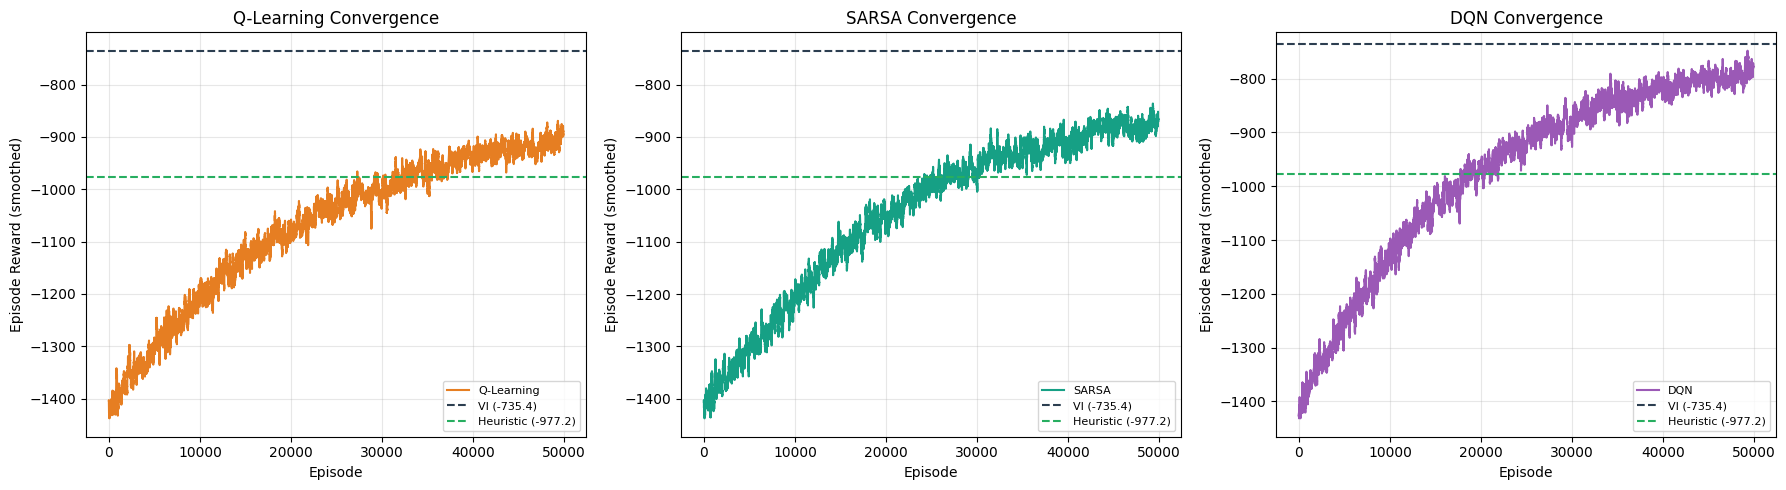

In [9]:
def smooth(data, window=100):
    """Moving average smoothing."""
    return np.convolve(data, np.ones(window)/window, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Q-Learning curve
ax = axes[0]
smoothed_q = smooth(q_rewards)
ax.plot(smoothed_q, color="#e67e22", linewidth=1.5, label="Q-Learning")
ax.axhline(y=vi_metrics["reward_mean"], color="#2c3e50", linestyle="--", label=f"VI ({vi_metrics['reward_mean']:.1f})")
ax.axhline(y=heuristic_metrics["reward_mean"], color="#27ae60", linestyle="--", label=f"Heuristic ({heuristic_metrics['reward_mean']:.1f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Episode Reward (smoothed)")
ax.set_title("Q-Learning Convergence")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# SARSA curve
ax = axes[1]
smoothed_sarsa = smooth(sarsa_rewards)
ax.plot(smoothed_sarsa, color="#16a085", linewidth=1.5, label="SARSA")
ax.axhline(y=vi_metrics["reward_mean"], color="#2c3e50", linestyle="--", label=f"VI ({vi_metrics['reward_mean']:.1f})")
ax.axhline(y=heuristic_metrics["reward_mean"], color="#27ae60", linestyle="--", label=f"Heuristic ({heuristic_metrics['reward_mean']:.1f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Episode Reward (smoothed)")
ax.set_title("SARSA Convergence")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# DQN curve
ax = axes[2]
smoothed_dqn = smooth(dqn_rewards)
ax.plot(smoothed_dqn, color="#9b59b6", linewidth=1.5, label="DQN")
ax.axhline(y=vi_metrics["reward_mean"], color="#2c3e50", linestyle="--", label=f"VI ({vi_metrics['reward_mean']:.1f})")
ax.axhline(y=heuristic_metrics["reward_mean"], color="#27ae60", linestyle="--", label=f"Heuristic ({heuristic_metrics['reward_mean']:.1f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Episode Reward (smoothed)")
ax.set_title("DQN Convergence")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, "learning_curves")
plt.show()


## 7. Comparison Table

In [10]:
import pandas as pd

all_metrics = {
    "Random": random_metrics,
    "Heuristic": heuristic_metrics,
    "Value Iteration": vi_metrics,
    "Q-Learning": q_metrics,
    "SARSA": sarsa_metrics,
    "DQN": dqn_metrics,
}

rows = []
for name, m in all_metrics.items():
    rows.append({
        "Method": name,
        "Avg Reward": f"{m['reward_mean']:.2f}",
        "Std Reward": f"{m['reward_std']:.2f}",
        "Avg Unmet Demand": f"{m['unmet_mean']:.2f}",
        "Service Level %": f"{m['service_level_mean']:.1f}",
        "Avg Imports": f"{m['imports_mean']:.1f}",
        "Avg Transfers": f"{m['transfers_mean']:.1f}",
        "Avg Infeasible": f"{m['infeasible_mean']:.1f}",
    })

df = pd.DataFrame(rows).set_index("Method")
print(df.to_string())
df


                Avg Reward Std Reward Avg Unmet Demand Service Level % Avg Imports Avg Transfers Avg Infeasible
Method                                                                                                         
Random            -1416.75     155.05           127.25            34.0        37.0          13.2           12.6
Heuristic          -977.21     109.25            86.28            55.2        79.4          14.5            0.0
Value Iteration    -735.44     108.16            54.04            72.1       111.8          29.2            0.1
Q-Learning         -856.50     104.16            68.86            64.4        96.9          20.0            0.3
SARSA              -841.07     108.43            64.34            66.7       101.7          16.6            0.0
DQN                -732.65     109.84            55.85            71.2       109.9          31.6            0.2


,Avg Reward,Std Reward,Avg Unmet Demand,Service Level %,Avg Imports,Avg Transfers,Avg Infeasible
Method,,,,,,,
Random,-1416.75,155.05,127.25,34.0,37.0,13.2,12.6
Heuristic,-977.21,109.25,86.28,55.2,79.4,14.5,0.0
Value Iteration,-735.44,108.16,54.04,72.1,111.8,29.2,0.1
Q-Learning,-856.50,104.16,68.86,64.4,96.9,20.0,0.3
SARSA,-841.07,108.43,64.34,66.7,101.7,16.6,0.0
DQN,-732.65,109.84,55.85,71.2,109.9,31.6,0.2


## 8. Bar Chart Comparison

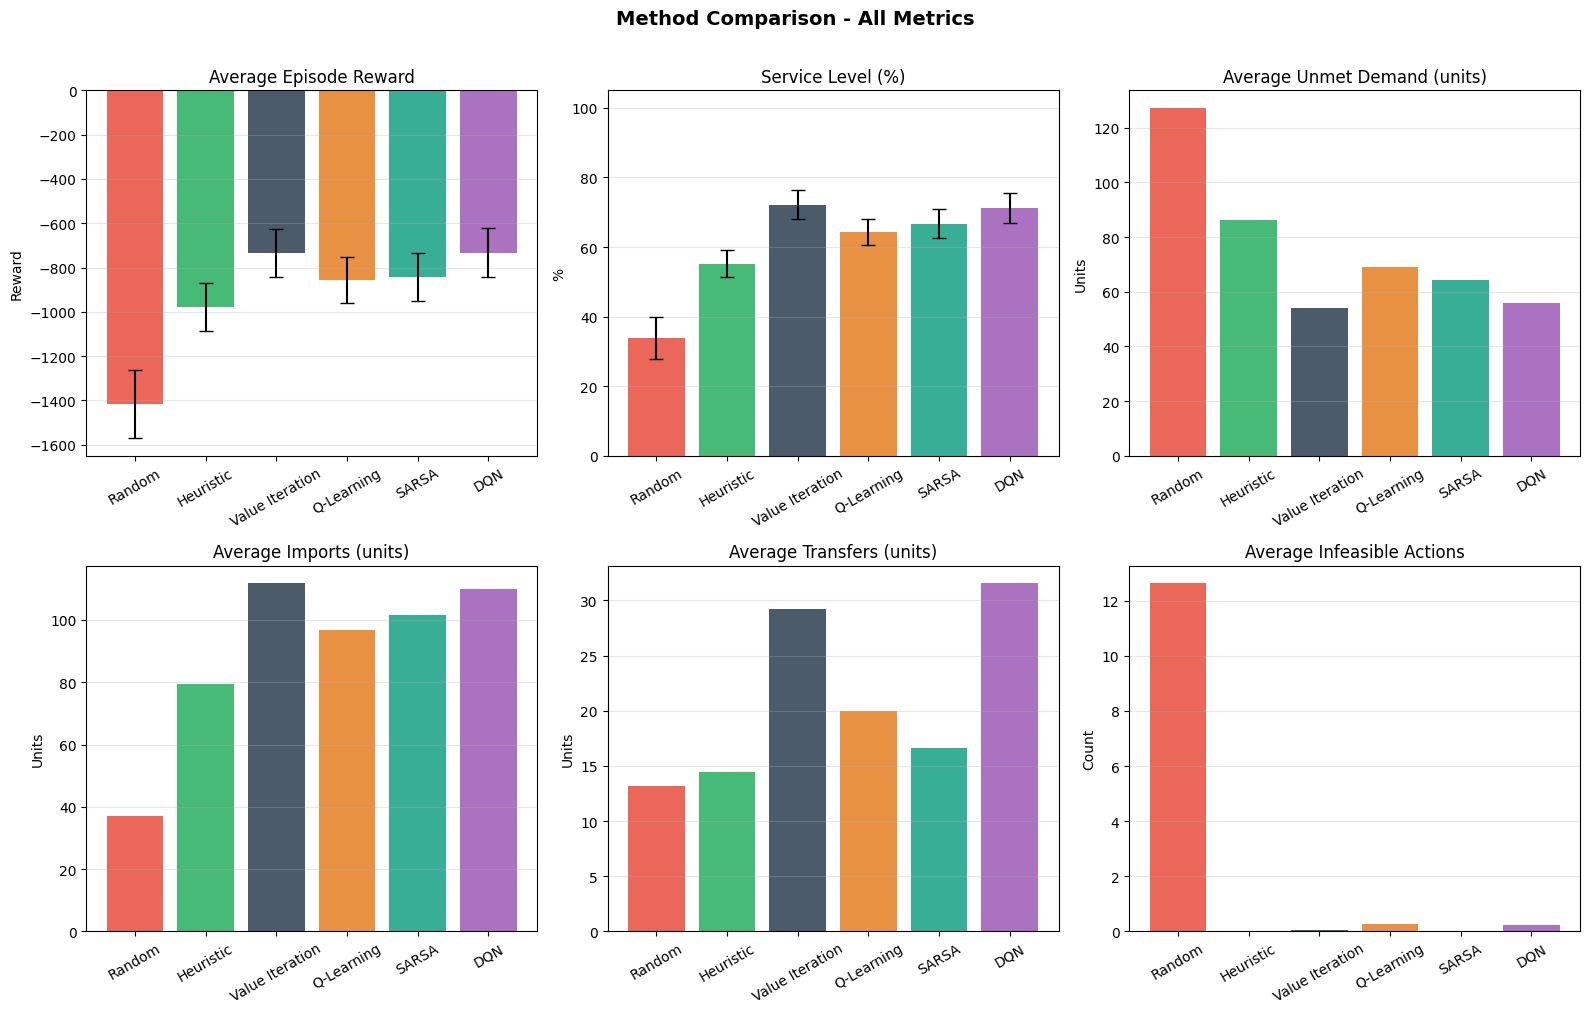

In [ ]:
method_names = list(all_metrics.keys())
method_colors = ["#e74c3c", "#27ae60", "#2c3e50", "#e67e22", "#16a085", "#9b59b6"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Average Reward
ax = axes[0, 0]
vals = [all_metrics[m]["reward_mean"] for m in method_names]
stds = [all_metrics[m]["reward_std"] for m in method_names]
bars = ax.bar(method_names, vals, color=method_colors, yerr=stds, capsize=5, alpha=0.85)
ax.set_title("Average Episode Reward")
ax.set_ylabel("Reward")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# Service Level
ax = axes[0, 1]
vals = [all_metrics[m]["service_level_mean"] for m in method_names]
stds = [all_metrics[m]["service_level_std"] for m in method_names]
ax.bar(method_names, vals, color=method_colors, yerr=stds, capsize=5, alpha=0.85)
ax.set_title("Service Level (%)")
ax.set_ylabel("%")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# Unmet Demand
ax = axes[0, 2]
vals = [all_metrics[m]["unmet_mean"] for m in method_names]
ax.bar(method_names, vals, color=method_colors, alpha=0.85)
ax.set_title("Average Unmet Demand (units)")
ax.set_ylabel("Units")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# Total Imports
ax = axes[1, 0]
vals = [all_metrics[m]["imports_mean"] for m in method_names]
ax.bar(method_names, vals, color=method_colors, alpha=0.85)
ax.set_title("Average Imports (units)")
ax.set_ylabel("Units")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# Total Transfers
ax = axes[1, 1]
vals = [all_metrics[m]["transfers_mean"] for m in method_names]
ax.bar(method_names, vals, color=method_colors, alpha=0.85)
ax.set_title("Average Transfers (units)")
ax.set_ylabel("Units")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# Infeasible Actions
ax = axes[1, 2]
vals = [all_metrics[m]["infeasible_mean"] for m in method_names]
ax.bar(method_names, vals, color=method_colors, alpha=0.85)
ax.set_title("Average Infeasible Actions")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Method Comparison - All Metrics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_figure(fig, "comparison_bars")
plt.show()

## 9. Reward Distribution (Box Plot)

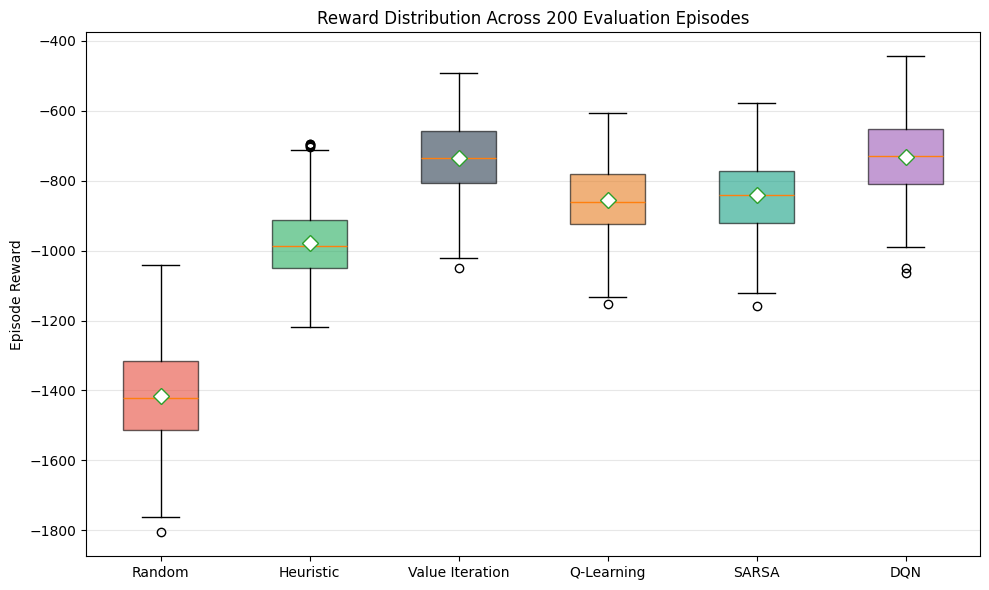

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

reward_data = [all_metrics[m]["rewards"] for m in method_names]
bp = ax.boxplot(reward_data, labels=method_names, patch_artist=True, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white", "markersize": 8})

for patch, color in zip(bp["boxes"], method_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Episode Reward")
ax.set_title("Reward Distribution Across 200 Evaluation Episodes")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_figure(fig, "reward_distribution")
plt.show()

## 10. Policy Analysis - Single Episode Trajectory

Visualize what each method does over 12 months: stock levels, actions taken, and demand vs fulfillment.

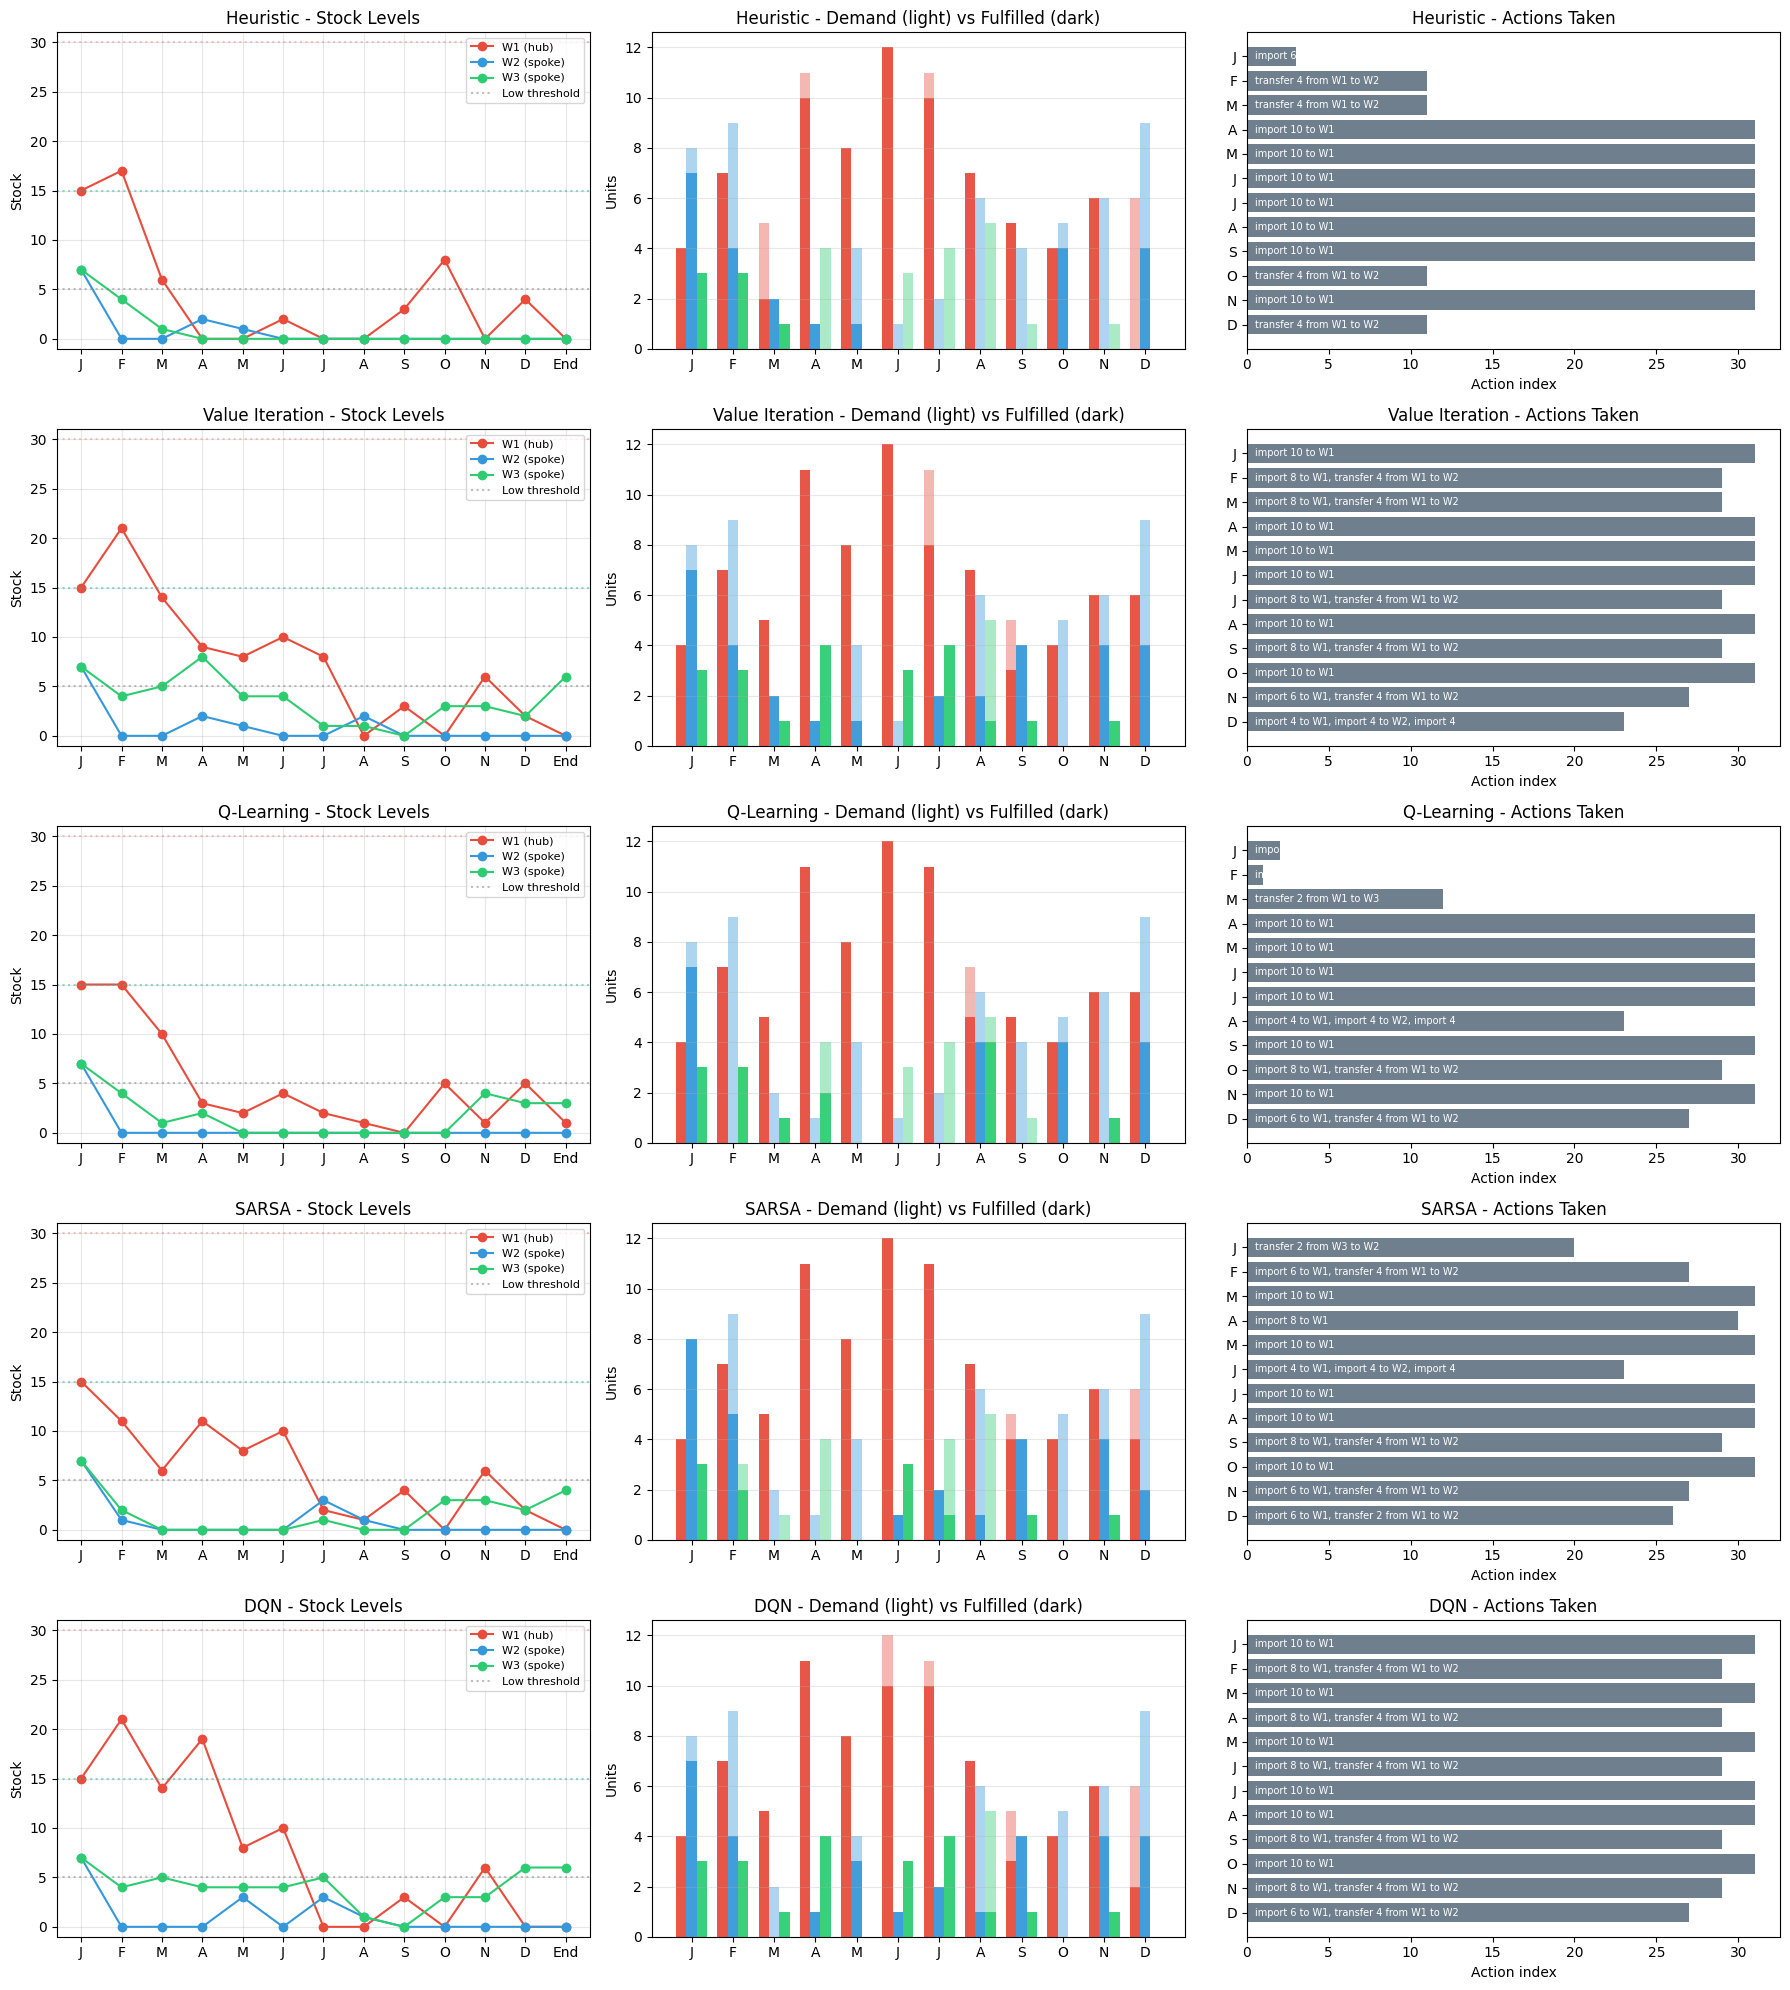

In [ ]:
def run_single_episode(policy_fn, seed=123):
    """Run one episode and record full trajectory."""
    ep_env = WarehouseEnv(capacities=CAPACITIES, n_months=N_MONTHS, seed=seed)
    state = ep_env.reset()
    
    trajectory = {
        "stocks": [list(ep_env.stocks)],
        "actions": [],
        "demands": [],
        "unmet": [],
        "imports": [],
        "transfers": [],
    }
    
    while True:
        action = policy_fn(state)
        next_state, reward, done, info = ep_env.step(action)
        
        trajectory["actions"].append(action)
        trajectory["demands"].append(info["demands"])
        trajectory["unmet"].append(info["unmet"])
        trajectory["imports"].append(info["actual_imports"])
        trajectory["transfers"].append(info["total_transferred"])
        trajectory["stocks"].append(list(ep_env.stocks))
        
        state = next_state
        if done:
            break
    
    return trajectory


policies = {
    "Heuristic": heuristic_policy,
    "Value Iteration": vi_policy,
    "Q-Learning": q_policy,
    "SARSA": sarsa_policy,
    "DQN": dqn_policy,
}

fig, axes = plt.subplots(len(policies), 3, figsize=(18, 4 * len(policies)))
month_labels_short = ["J","F","M","A","M","J","J","A","S","O","N","D"]

for row, (name, pol) in enumerate(policies.items()):
    traj = run_single_episode(pol)
    
    stocks = np.array(traj["stocks"])  
    demands = np.array(traj["demands"])  
    unmet = np.array(traj["unmet"]) 
    imports = np.array(traj["imports"])  
    
    # Stock levels over time
    ax = axes[row, 0]
    for i in range(3):
        ax.plot(range(13), stocks[:, i], "o-", color=colors[i], label=wh_names[i])
        ax.axhline(y=CAPACITIES[i], color=colors[i], linestyle=":", alpha=0.3)
    ax.axhline(y=5, color="gray", linestyle=":", alpha=0.5, label="Low threshold")
    ax.set_ylabel("Stock")
    ax.set_title(f"{name} - Stock Levels")
    ax.set_xticks(range(13))
    ax.set_xticklabels(month_labels_short + ["End"])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1, max(CAPACITIES) + 1)
    
    # Demand vs fulfillment
    ax = axes[row, 1]
    x = np.arange(12)
    width = 0.25
    for i in range(3):
        ax.bar(x + i * width - width, demands[:, i], width, color=colors[i], alpha=0.4, label=f"{wh_names[i]} demand")
        ax.bar(x + i * width - width, demands[:, i] - unmet[:, i], width, color=colors[i], alpha=0.9)
    ax.set_ylabel("Units")
    ax.set_title(f"{name} - Demand (light) vs Fulfilled (dark)")
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels_short)
    ax.grid(axis="y", alpha=0.3)
    
    # Actions taken
    ax = axes[row, 2]
    action_labels = [env.describe_action(a)[:40] for a in traj["actions"]]
    ax.barh(range(12), [traj["actions"][i] for i in range(12)], color="#34495e", alpha=0.7)
    for i, label in enumerate(action_labels):
        ax.text(0.5, i, label, va="center", fontsize=7, color="white")
    ax.set_yticks(range(12))
    ax.set_yticklabels(month_labels_short)
    ax.set_xlabel("Action index")
    ax.set_title(f"{name} - Actions Taken")
    ax.invert_yaxis()

plt.tight_layout()
save_figure(fig, "single_episode_trajectory")
plt.show()

## 11. Epsilon Decay Visualization

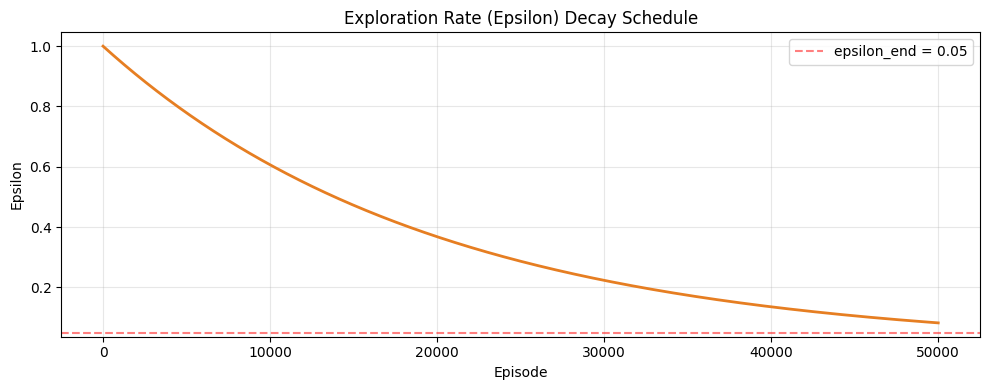

In [14]:
eps = EPSILON_START
eps_history = []
for i in range(TRAIN_EPISODES):
    eps_history.append(eps)
    eps = max(EPSILON_END, eps * EPSILON_DECAY)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eps_history, color="#e67e22", linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Epsilon")
ax.set_title("Exploration Rate (Epsilon) Decay Schedule")
ax.grid(True, alpha=0.3)
ax.axhline(y=EPSILON_END, color="red", linestyle="--", alpha=0.5, label=f"epsilon_end = {EPSILON_END}")
ax.legend()
plt.tight_layout()
save_figure(fig, "epsilon_decay")
plt.show()

## 12. Q-Learning vs SARSA vs DQN - Combined Learning Curve

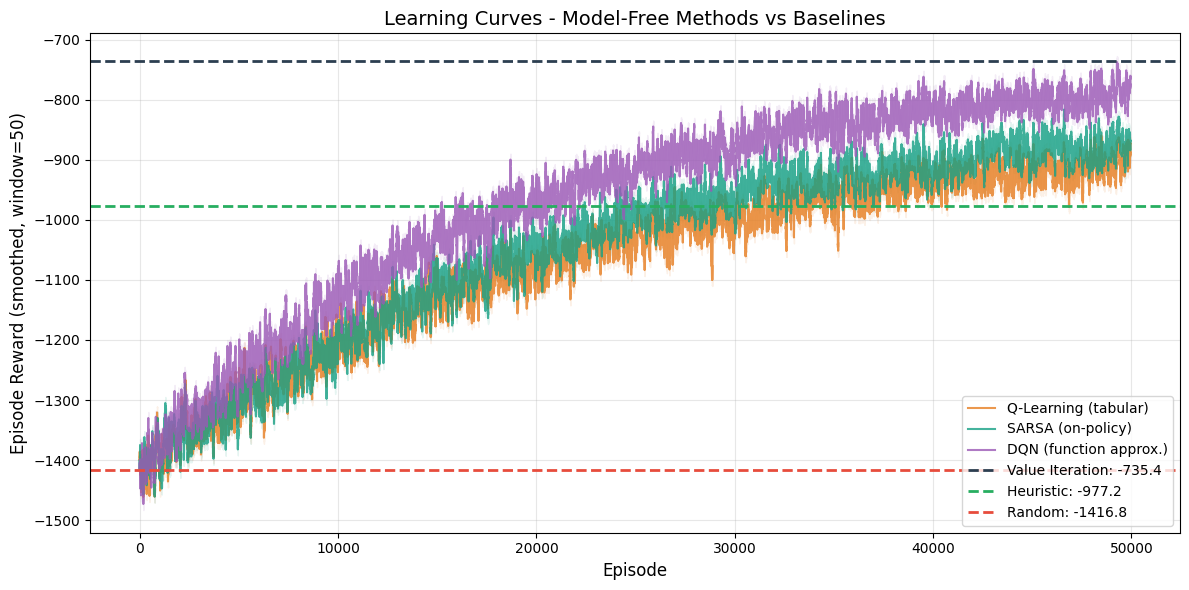

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(smooth(q_rewards, 50), color="#e67e22", alpha=0.8, linewidth=1.5, label="Q-Learning (tabular)")
ax.plot(smooth(sarsa_rewards, 50), color="#16a085", alpha=0.8, linewidth=1.5, label="SARSA (on-policy)")
ax.plot(smooth(dqn_rewards, 50), color="#9b59b6", alpha=0.8, linewidth=1.5, label="DQN (function approx.)")

ax.axhline(y=vi_metrics["reward_mean"], color="#2c3e50", linestyle="--", linewidth=2, label=f"Value Iteration: {vi_metrics['reward_mean']:.1f}")
ax.axhline(y=heuristic_metrics["reward_mean"], color="#27ae60", linestyle="--", linewidth=2, label=f"Heuristic: {heuristic_metrics['reward_mean']:.1f}")
ax.axhline(y=random_metrics["reward_mean"], color="#e74c3c", linestyle="--", linewidth=2, label=f"Random: {random_metrics['reward_mean']:.1f}")

ax.fill_between(range(len(smooth(q_rewards, 50))),
                smooth(q_rewards, 50) - 10,
                smooth(q_rewards, 50) + 10,
                color="#e67e22", alpha=0.1)
ax.fill_between(range(len(smooth(sarsa_rewards, 50))),
                smooth(sarsa_rewards, 50) - 10,
                smooth(sarsa_rewards, 50) + 10,
                color="#16a085", alpha=0.1)
ax.fill_between(range(len(smooth(dqn_rewards, 50))),
                smooth(dqn_rewards, 50) - 10,
                smooth(dqn_rewards, 50) + 10,
                color="#9b59b6", alpha=0.1)

ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Episode Reward (smoothed, window=50)", fontsize=12)
ax.set_title("Learning Curves - Model-Free Methods vs Baselines", fontsize=14)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure(fig, "combined_learning_curve")
plt.show()


## 13. Per-Warehouse Import & Transfer Breakdown

Average imports and transfers (in/out) per warehouse across 200 evaluation episodes. This shows whether the hub-and-spoke structure is working: W1 (hub) should dominate imports and outbound transfers.

In [ ]:
# Per-Warehouse Import & Transfer Table
method_names = list(all_metrics.keys())
wh_labels = ["W1 (hub)", "W2 (spoke)", "W3 (spoke)"]

rows = []
for name in method_names:
    m = all_metrics[name]
    imp = m["imports_per_wh"]
    t_in = m["transfers_in_per_wh"]
    t_out = m["transfers_out_per_wh"]
    for w in range(3):
        rows.append({
            "Method": name,
            "Warehouse": wh_labels[w],
            "Avg Imports": f"{imp[w]:.1f}",
            "Avg Transfers In": f"{t_in[w]:.1f}",
            "Avg Transfers Out": f"{t_out[w]:.1f}",
            "Net Transfer": f"{t_in[w] - t_out[w]:+.1f}",
        })

df_wh = pd.DataFrame(rows)
print(df_wh.to_string(index=False))
df_wh

         Method  Warehouse Avg Imports Avg Transfers In Avg Transfers Out Net Transfer
         Random   W1 (hub)        24.7              1.4              10.4         -9.0
         Random W2 (spoke)         6.0              6.4               1.0         +5.4
         Random W3 (spoke)         6.2              5.5               1.8         +3.6
      Heuristic   W1 (hub)        79.4              0.0              14.5        -14.5
      Heuristic W2 (spoke)         0.0             14.2               0.0        +14.2
      Heuristic W3 (spoke)         0.0              0.3               0.0         +0.3
Value Iteration   W1 (hub)       106.7              0.0              29.2        -29.2
Value Iteration W2 (spoke)         2.5             15.9               0.0        +15.9
Value Iteration W3 (spoke)         2.5             13.3               0.0        +13.3
     Q-Learning   W1 (hub)        89.8              0.4              19.2        -18.8
     Q-Learning W2 (spoke)         3.6     

,Method,Warehouse,Avg Imports,Avg Transfers In,Avg Transfers Out,Net Transfer
0,Random,W1 (hub),24.7,1.4,10.4,-9.0
1,Random,W2 (spoke),6.0,6.4,1.0,+5.4
2,Random,W3 (spoke),6.2,5.5,1.8,+3.6
3,Heuristic,W1 (hub),79.4,0.0,14.5,-14.5
4,Heuristic,W2 (spoke),0.0,14.2,0.0,+14.2
5,Heuristic,W3 (spoke),0.0,0.3,0.0,+0.3
6,Value Iteration,W1 (hub),106.7,0.0,29.2,-29.2
7,Value Iteration,W2 (spoke),2.5,15.9,0.0,+15.9
8,Value Iteration,W3 (spoke),2.5,13.3,0.0,+13.3
9,Q-Learning,W1 (hub),89.8,0.4,19.2,-18.8


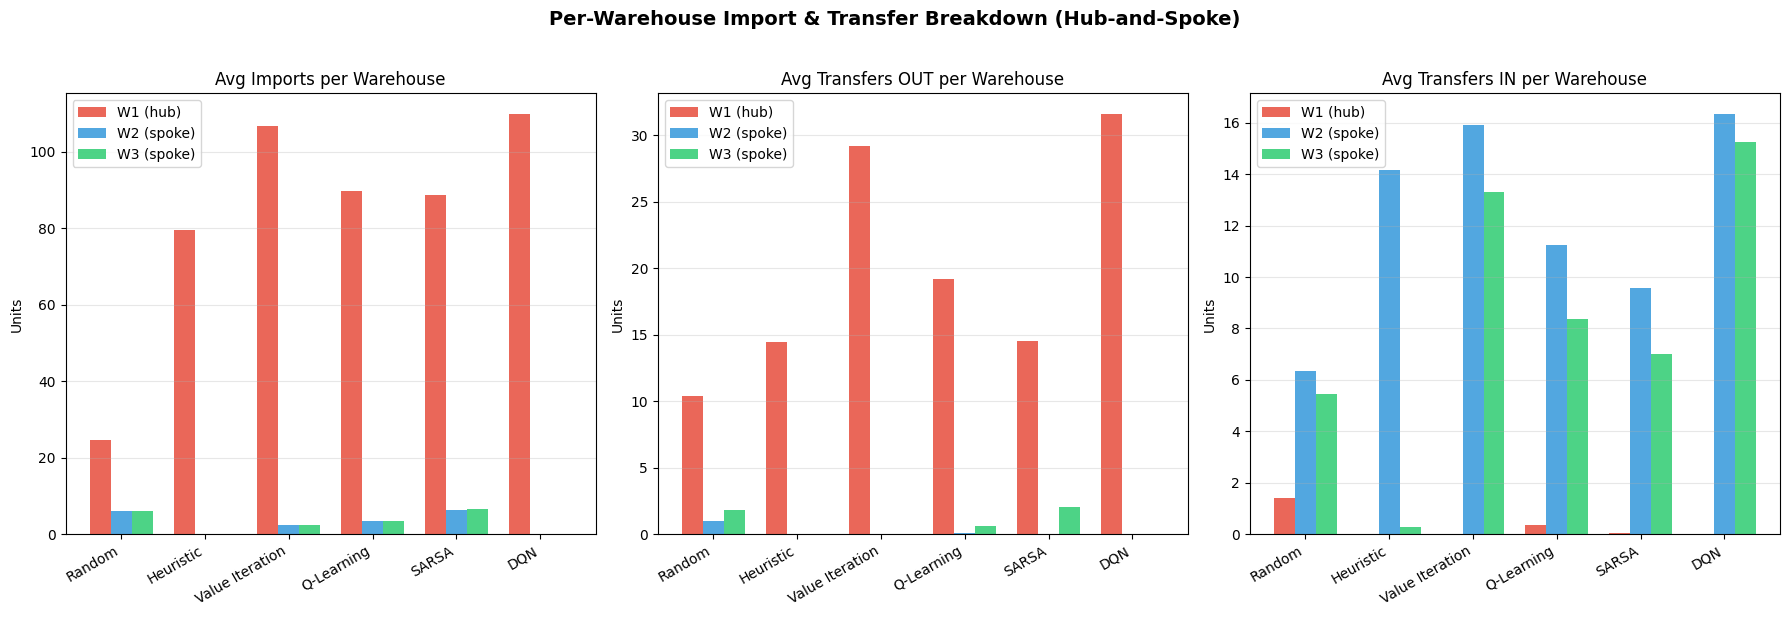

In [ ]:
# Per-Warehouse Import & Transfer Graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
method_names_list = list(all_metrics.keys())
x = np.arange(len(method_names_list))
width = 0.25
wh_colors = ["#e74c3c", "#3498db", "#2ecc71"]
wh_labels = ["W1 (hub)", "W2 (spoke)", "W3 (spoke)"]

# Imports per warehouse
ax = axes[0]
for w in range(3):
    vals = [all_metrics[m]["imports_per_wh"][w] for m in method_names_list]
    ax.bar(x + w * width - width, vals, width, color=wh_colors[w], label=wh_labels[w], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(method_names_list, rotation=30, ha="right")
ax.set_ylabel("Units")
ax.set_title("Avg Imports per Warehouse")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Transfers OUT per warehouse
ax = axes[1]
for w in range(3):
    vals = [all_metrics[m]["transfers_out_per_wh"][w] for m in method_names_list]
    ax.bar(x + w * width - width, vals, width, color=wh_colors[w], label=wh_labels[w], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(method_names_list, rotation=30, ha="right")
ax.set_ylabel("Units")
ax.set_title("Avg Transfers OUT per Warehouse")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Transfers IN per warehouse
ax = axes[2]
for w in range(3):
    vals = [all_metrics[m]["transfers_in_per_wh"][w] for m in method_names_list]
    ax.bar(x + w * width - width, vals, width, color=wh_colors[w], label=wh_labels[w], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(method_names_list, rotation=30, ha="right")
ax.set_ylabel("Units")
ax.set_title("Avg Transfers IN per Warehouse")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Per-Warehouse Import & Transfer Breakdown (Hub-and-Spoke)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "warehouse_transfer_breakdown")
plt.show()

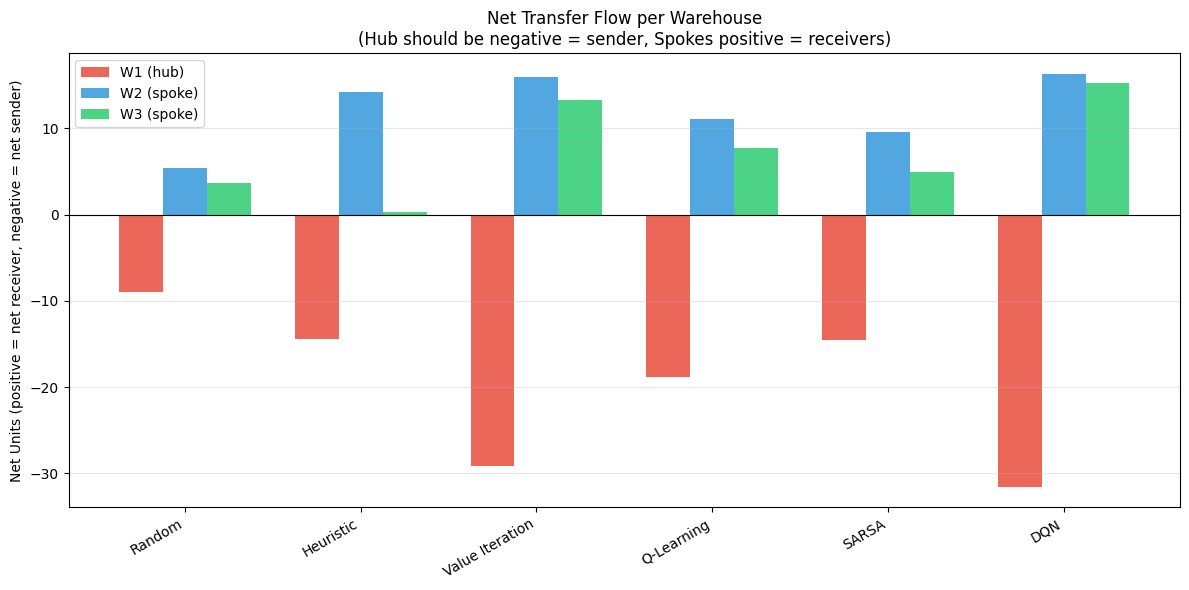

In [ ]:
# Net Transfer Flow Hub vs Spokes
fig, ax = plt.subplots(figsize=(12, 6))
method_names_list = list(all_metrics.keys())
x = np.arange(len(method_names_list))
width = 0.25

for w in range(3):
    net_vals = [
        all_metrics[m]["transfers_in_per_wh"][w] - all_metrics[m]["transfers_out_per_wh"][w]
        for m in method_names_list
    ]
    ax.bar(x + w * width - width, net_vals, width, color=wh_colors[w], label=wh_labels[w], alpha=0.85)

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(method_names_list, rotation=30, ha="right")
ax.set_ylabel("Net Units (positive = net receiver, negative = net sender)")
ax.set_title("Net Transfer Flow per Warehouse\n(Hub should be negative = sender, Spokes positive = receivers)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_figure(fig, "net_transfer_flow")
plt.show()